In [1]:
# -*- coding: utf-8 -*-
"""
modalanalysis_owt
----------

Driver for Modal analysis of beam/Frame structure.

Created: June 2020

@author: Oscar Bondo Ellekvist, s163774
         Modified spring 2026 for owt case with ship impact
     
"""

# Import packages
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sys

# Import functions
from timestep import timestep
from scipy import linalg as linalg

### INPUT
npzfile = np.load('owt_XKM.npz')
X   = npzfile['X']
K   = npzfile['K']
M   = npzfile['M']

### NODES and GEOMETRY
# Dimensions of 3D FE model = 6 dofs per node: 
# [disp_x disp_y disp_z rot_x rot_y rot_z] in global {x,y,z}-coord sys.
dof  = 6
ndof = np.size(X,1)*dof
print(ndof)

# eigenvalue problem
n_modes = 50
[lam,U] = sp.linalg.eigh(K, M, subset_by_index=[0, n_modes - 1])
lam = np.real(lam)
omega = np.sqrt(lam)
iw = np.argsort(omega)


omega = omega[iw]
freq  = omega/(2*np.pi)
U = U[:,iw]
U = U / U[np.argmax(np.abs(U), axis=0), np.arange(0, n_modes)]

1674


In [2]:
# Assuming mode_plot is the mode you are interested in (e.g., 1, 2, or 13)
m_idx = 0

# Extract the translation components
ux = U[0::6, m_idx]
uy = U[1::6, m_idx]
uz = U[2::6, m_idx]

# Calculate Mean Magnitudes
mean_ux = np.mean(np.abs(ux))
mean_uy = np.mean(np.abs(uy))
mean_uz = np.mean(np.abs(uz))

# Calculate Maximum Magnitudes
max_ux = np.max(np.abs(ux))
max_uy = np.max(np.abs(uy))
max_uz = np.max(np.abs(uz))

total_mag = mean_ux + mean_uy + mean_uz
print(f"--- Mode {m_idx} Comparison ---")
print(f"X-Dominance: {(mean_ux/total_mag)*100:.2f}%")
print(f"Y-Dominance: {(mean_uy/total_mag)*100:.2f}%")
print(f"Z-Dominance: {(mean_uz/total_mag)*100:.2f}%")

if mean_ux > mean_uy and mean_ux > mean_uz:
    print("Result: Mode is dominated by x displacement.")
elif mean_uy > mean_ux and mean_uy > mean_uz:
    print("Result: Mode is dominated by y displacement.")
else:
    print("Result: Mode is dominated by z displacement.")

--- Mode 0 Comparison ---
X-Dominance: 69.60%
Y-Dominance: 7.27%
Z-Dominance: 23.13%
Result: Mode is dominated by x displacement.


In [3]:
# Define the range for the monopile (0 to 64)
mono_range = slice(0, 65) 

# Assuming m_idx is the mode you are interested in (e.g., 0, 1, or 12)
m_idx = 0  # Mode 1

# 1. Extract the translation components for the MONOPILE ONLY
ux_mono = U[0::6, m_idx][mono_range]
uy_mono = U[1::6, m_idx][mono_range]
uz_mono = U[2::6, m_idx][mono_range]

# 2. Calculate Mean Magnitudes for the Monopile
mean_ux = np.mean(np.abs(ux_mono))
mean_uy = np.mean(np.abs(uy_mono))
mean_uz = np.mean(np.abs(uz_mono))

# 3. Calculate Maximum Magnitudes for the Monopile
max_ux = np.max(np.abs(ux_mono))
max_uy = np.max(np.abs(uy_mono))
max_uz = np.max(np.abs(uz_mono))

# 4. Calculate Dominance
total_mag = mean_ux + mean_uy + mean_uz

print(f"--- Monopile Analysis (Nodes 0-64) | Mode {m_idx + 1} ---")
print(f"X-Dominance: {(mean_ux/total_mag)*100:.2f}%")
print(f"Y-Dominance: {(mean_uy/total_mag)*100:.2f}%")
print(f"Z-Dominance: {(mean_uz/total_mag)*100:.2f}%")

if mean_ux > mean_uy and mean_ux > mean_uz:
    print("Result: Monopile is dominated by x displacement (Side-Side).")
elif mean_uy > mean_ux and mean_uy > mean_uz:
    print("Result: Monopile is dominated by y displacement (Fore-Aft).")
else:
    print("Result: Monopile is dominated by z displacement (Vertical).")
    
print(f"Peak Monopile Displacement: {max(max_ux, max_uy, max_uz):.4f}")

--- Monopile Analysis (Nodes 0-64) | Mode 1 ---
X-Dominance: 92.58%
Y-Dominance: 7.42%
Z-Dominance: 0.00%
Result: Monopile is dominated by x displacement (Side-Side).
Peak Monopile Displacement: 0.3718


In [4]:
# Initial conditions
x0 = np.zeros((ndof,1),dtype=float)
v0 = x0

# Damping ratio (constant modal damping) for all modes included
zeta = 0.025

# Time simulation parameters
t0 = 0                  # initial time
N  = 20000              # number of time steps
dt = 0.001              # time step size

# Load vector - sine at node 50 in y-direction
nodef = 50
tf = np.arange(0,N+1,1,dtype=float)*dt   # time vector
omegaf = omega[13-1]
freqf = freq[13-1]
Tf = 1/freqf
F = np.zeros((ndof,N+1),dtype=float)
F[(nodef-1)*6+2-1,:] = 1e6*np.sin(omegaf*tf)

# plot force
# fig10 = plt.figure(10,figsize=[6,4])
# plt.plot(tf,F[(nodef-1)*6+2-1,:]*1e-6,color='blue')
# plt.title('Double-impact load')
# plt.xlabel(r'$t$ - [s]', fontsize=14)
# plt.ylabel(r'$f$ - [MN]', fontsize=14)
# plt.grid()
# plt.xlim([0, 4])
#plt.ylim([-0.01, 0.01])
#plt.show()

print(freq[0:15])



[0.18480679 0.18563403 0.40530375 0.42205058 0.43898131 0.57192781
 0.61689922 0.62078996 1.06751549 1.14817718 1.25640636 1.33217116
 1.45702771 1.69042202 1.70138315]


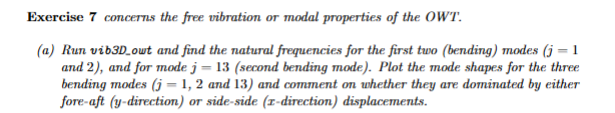

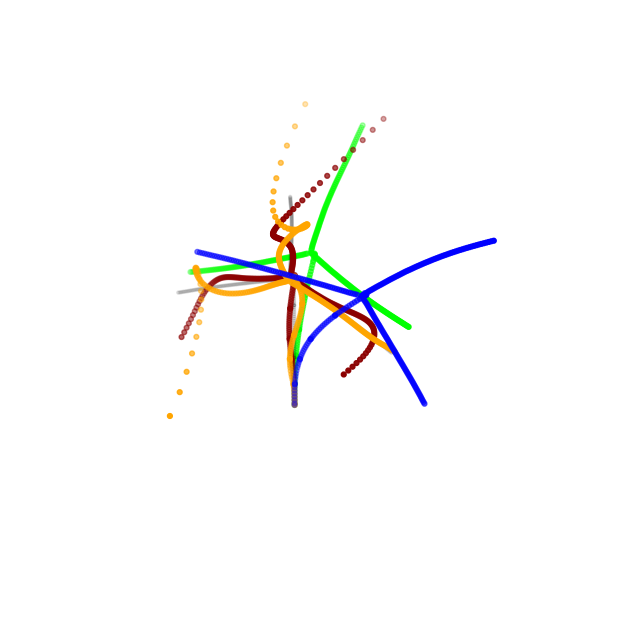

In [5]:
### 3D PLOT: MONOPILE COMPARISON (ZERO-INDEXED)
plt.close('all')

# 1. Define the 3 modes using raw Python indices
# Index 0 = 1st Mode, Index 1 = 2nd Mode, Index 12 = 13th Mode
modes_to_plot = [0, 1, 12, 20]  
mode_scl = 150                 
mono_slice = slice(0, 278)     

# Extract Monopile Coordinates
X_mono = X[:, mono_slice]

# Setup Figure
fig = plt.figure(figsize=[10, 8])
ax = fig.add_subplot(111, projection='3d')

# 2. Plot Static Monopile (Background reference - No Label)
ax.scatter(X_mono[0, :], X_mono[1, :], X_mono[2, :], 
           color='k', marker='.', alpha=0.1, label='_nolegend_')

# 3. Define colors for the 4 specific indices
colors = ['blue', 'lime', 'darkred', 'orange']

for i, m_idx in enumerate(modes_to_plot):
    # --- DATA EXTRACTION (Directly using m_idx) ---
    ux_raw = U[0::6, m_idx][mono_slice]
    uy_raw = U[1::6, m_idx][mono_slice]
    uz_raw = U[2::6, m_idx][mono_slice]
    
    # --- DOMINANCE CALCULATION ---
    mean_x = np.mean(np.abs(ux_raw))
    mean_y = np.mean(np.abs(uy_raw))
    mean_z = np.mean(np.abs(uz_raw))
    
    total = mean_x + mean_y + mean_z
    px, py, pz = (mean_x/total)*100, (mean_y/total)*100, (mean_z/total)*100
    
    # Determine the dominance string
    if px > py and px > pz:
        dom_label = f"Dom X ({px:.1f}%)"
    elif py > px and py > pz:
        dom_label = f"Dom Y ({py:.1f}%)"
    else:
        dom_label = f"Dom Z ({pz:.1f}%)"
    
    # 4. Plot each mode with Zero-Indexed Legend Label
    ax.scatter(
        X_mono[0, :] + ux_raw * mode_scl, 
        X_mono[1, :] + uy_raw * mode_scl, 
        X_mono[2, :] + uz_raw * mode_scl,  
        color=colors[i], 
        marker='o', 
        s=12, 
        label=f'Index {m_idx}: {dom_label}'
    )

# Remove panes (the gray background planes)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Remove pane edges
ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')

# Remove grid
ax.grid(False)

# Remove axes ticks and labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])


# Optional: remove axis lines completely
ax.set_axis_off()

In [6]:
# Modes to analyze (1, 2, and 13)
modes_to_analyze = [0, 1, 12] 

for m_idx in modes_to_analyze:
    # 1. Extract absolute displacements for each direction
    ux = np.abs(U[0::6, m_idx])
    uy = np.abs(U[1::6, m_idx])
    uz = np.abs(U[2::6, m_idx])

    # 2. Calculate the mean of each direction
    mean_x = np.mean(ux)
    mean_y = np.mean(uy)
    mean_z = np.mean(uz)

    # 3. Calculate Total Mean Magnitude
    total_mean = mean_x + mean_y + mean_z

    # 4. Calculate Percentages
    perc_x = (mean_x / total_mean) * 100
    perc_y = (mean_y / total_mean) * 100
    perc_z = (mean_z / total_mean) * 100

    print(f"--- Mode {m_idx + 1} Directional Breakdown ---")
    print(f"Mean X: {mean_x:.4e} ({perc_x:.2f}%)")
    print(f"Mean Y: {mean_y:.4e} ({perc_y:.2f}%)")
    print(f"Mean Z: {mean_z:.4e} ({perc_z:.2f}%)")
    
    # Identify Dominance
    directions = {'X (Side-Side)': perc_x, 'Y (Fore-Aft)': perc_y, 'Z (Vertical)': perc_z}
    dominant = max(directions, key=directions.get)
    print(f"Result: Mode {m_idx + 1} is dominated by {dominant} motion.\n")

--- Mode 1 Directional Breakdown ---
Mean X: 3.2433e-01 (69.60%)
Mean Y: 3.3865e-02 (7.27%)
Mean Z: 1.0781e-01 (23.13%)
Result: Mode 1 is dominated by X (Side-Side) motion.

--- Mode 2 Directional Breakdown ---
Mean X: 2.0921e-02 (6.25%)
Mean Y: 2.8806e-01 (86.05%)
Mean Z: 2.5774e-02 (7.70%)
Result: Mode 2 is dominated by Y (Fore-Aft) motion.

--- Mode 13 Directional Breakdown ---
Mean X: 1.3712e-02 (13.85%)
Mean Y: 6.3994e-02 (64.66%)
Mean Z: 2.1265e-02 (21.49%)
Result: Mode 13 is dominated by Y (Fore-Aft) motion.



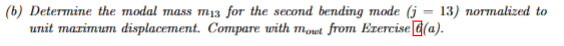

In [7]:
### MODAL ANALYSIS

# Modal mass and stiffness
mm = np.linalg.multi_dot((np.transpose(U),M,U))
km = np.linalg.multi_dot((np.transpose(U),K,U))

# Initial conditions
r0 = np.linalg.solve(mm,np.linalg.multi_dot((np.transpose(U),M,x0)))
dr0 = np.linalg.solve(mm,np.linalg.multi_dot((np.transpose(U),M,v0)))

# Modal load
f = np.dot(np.transpose(U),F)

In [8]:

# 1. Extract modal mass for j=13 (index 12)
m13 = mm[12, 12]

m0 = mm[0, 0]
print(f"Modal mass m0: {m0:.2f} kg")

m1 = mm[1, 1]
print(f"Modal mass m1: {m1:.2f} kg")
# 2. Assume m_owt is the value you found in Exercise 6(a)
# (Replace this with the actual numerical value from your previous work)
m_owt = 6575.3212 # Tons

# 3. Calculate the ratio
mass_ratio = m13 / m_owt

print(f"Modal mass m13: {m13:.2f} kg")
print(f"Physical mass m_owt: {m_owt:.2f} tons")
print(f"Ratio (m13 / m_owt): {mass_ratio:.4f}")

Modal mass m0: 116288.63 kg
Modal mass m1: 77544.08 kg
Modal mass m13: 2116.52 kg
Physical mass m_owt: 6575.32 tons
Ratio (m13 / m_owt): 0.3219


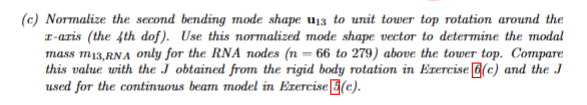

In [9]:
### CORRECTED EXERCISE 7(c)
m_idx = 12 
u13_raw = U[:, m_idx]

# 1. Normalize at Tower Top (Node 65)
# If the RNA starts at 66, the tower top is 65.
node_tt = 0
target_dof_index = (node_tt * 6) + 4 - 1
u13_norm_rot = u13_raw / u13_raw[target_dof_index]

# 2. Define the RNA DOF range 
# Change 280 to 279 so the highest index is node 278
rna_node_range = np.arange(65, 279) 
rna_dofs = []

for node in rna_node_range:
    start_dof = node * 6
    end_dof = (node + 1) * 6
    # This will now stop at (278 + 1) * 6 = 1674
    # The last index accessed will be 1673.
    rna_dofs.extend(range(start_dof, end_dof))

# 3. Extract and Calculate
u13_rna_sub = u13_norm_rot[rna_dofs]
M_rna_sub = M[np.ix_(rna_dofs, rna_dofs)]

m13_RNA = np.dot(u13_rna_sub.T, np.dot(M_rna_sub, u13_rna_sub))

print(f"Modal mass m13_RNA: {m13_RNA:.4f}")

Modal mass m13_RNA: 176527733.4872
